# Tornado Data — Exploratory Data Analysis

### See what columns are available in the storm event details.

In [1]:
import gzip
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Loading in one file to explore the data.
sample_file = sorted(glob.glob("../data/raw/StormEvents_details-ftp_v1.0_d*.csv.gz"))[0]
with gzip.open(sample_file, "rt", encoding="latin-1") as f:
    sample_df = pd.read_csv(f, low_memory=False)

print(f"File: {sample_file.split('/')[-1]}")

print("\nAll columns:")
for col in sample_df.columns:
    print(f"  {col}")

print("\nEvent types in this file:")
for event_type, count in sample_df["EVENT_TYPE"].value_counts().items():
    print(f"  {event_type:25s} {count}")
    
print("\nColumn data types:")
print(sample_df.dtypes.to_string())

File: StormEvents_details-ftp_v1.0_d1990_c20260323.csv.gz

All columns:
  BEGIN_YEARMONTH
  BEGIN_DAY
  BEGIN_TIME
  END_YEARMONTH
  END_DAY
  END_TIME
  EPISODE_ID
  EVENT_ID
  STATE
  STATE_FIPS
  YEAR
  MONTH_NAME
  EVENT_TYPE
  CZ_TYPE
  CZ_FIPS
  CZ_NAME
  WFO
  BEGIN_DATE_TIME
  CZ_TIMEZONE
  END_DATE_TIME
  INJURIES_DIRECT
  INJURIES_INDIRECT
  DEATHS_DIRECT
  DEATHS_INDIRECT
  DAMAGE_PROPERTY
  DAMAGE_CROPS
  SOURCE
  MAGNITUDE
  MAGNITUDE_TYPE
  FLOOD_CAUSE
  CATEGORY
  TOR_F_SCALE
  TOR_LENGTH
  TOR_WIDTH
  TOR_OTHER_WFO
  TOR_OTHER_CZ_STATE
  TOR_OTHER_CZ_FIPS
  TOR_OTHER_CZ_NAME
  BEGIN_RANGE
  BEGIN_AZIMUTH
  BEGIN_LOCATION
  END_RANGE
  END_AZIMUTH
  END_LOCATION
  BEGIN_LAT
  BEGIN_LON
  END_LAT
  END_LON
  EPISODE_NARRATIVE
  EVENT_NARRATIVE
  DATA_SOURCE

Event types in this file:
  Thunderstorm Wind         6063
  Hail                      3618
  Tornado                   1264

Column data types:
BEGIN_YEARMONTH         int64
BEGIN_DAY               int64
BEGIN_TIME  

### Columns to explore:

**Magnitude** - Strength of the tornado. Will need to processes into a number since there are EF and F ratings.

**Begin location and end location** - Extract where the event started and ended. Could potentially draw a straight line between the two.

**Begin Time and End Time** - Extract how long an event was.

**Injuries and Deaths** - Extract a human toll number. Deaths could count as 10 times an injury. Should indirect casualties be weighted differently?

**Damage** - Damage to properties and crops. What units is this measuredd in?


### First load in all of the storm data and filter for Tornado events only.

In [2]:
frames = []

for path in sorted(glob.glob("../data/raw/StormEvents_details-ftp_v1.0_d*.csv.gz")):
    fname = path.split("/")[-1]
    with gzip.open(path, "rt") as f:
        df = pd.read_csv(f, low_memory=False)
    df = df[df["EVENT_TYPE"].str.upper() == "TORNADO"].copy()
    df["year"] = path.split('_')[-2].split('d')[1]
    frames.append(df)
    print(f"  {fname}  :  {len(df)} tornado events")

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal tornado events loaded: {len(df)}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")

  StormEvents_details-ftp_v1.0_d1990_c20260323.csv.gz  :  1264 tornado events
  StormEvents_details-ftp_v1.0_d1991_c20260323.csv.gz  :  1208 tornado events
  StormEvents_details-ftp_v1.0_d1992_c20260323.csv.gz  :  1404 tornado events
  StormEvents_details-ftp_v1.0_d1993_c20260323.csv.gz  :  617 tornado events
  StormEvents_details-ftp_v1.0_d1994_c20260323.csv.gz  :  947 tornado events
  StormEvents_details-ftp_v1.0_d1995_c20260323.csv.gz  :  1222 tornado events
  StormEvents_details-ftp_v1.0_d1996_c20260323.csv.gz  :  1240 tornado events
  StormEvents_details-ftp_v1.0_d1997_c20260323.csv.gz  :  1180 tornado events
  StormEvents_details-ftp_v1.0_d1998_c20260323.csv.gz  :  1529 tornado events
  StormEvents_details-ftp_v1.0_d1999_c20260323.csv.gz  :  1520 tornado events
  StormEvents_details-ftp_v1.0_d2000_c20260323.csv.gz  :  1169 tornado events
  StormEvents_details-ftp_v1.0_d2001_c20260323.csv.gz  :  1351 tornado events
  StormEvents_details-ftp_v1.0_d2002_c20260323.csv.gz  :  1040 tor

### Determine availability of EF or F scale.

It looks like less than a percent of tornados are unrated. We can throw those events out.

Total tornado events : 49437
Have a magnitude     : 49353  (99.8%)
Missing magnitude    : 84  (0.2%)

Breakdown by rating:
TOR_F_SCALE
F0     13074
EF0    12741
EF1     9752
F1      5839
EF2     2650
F2      1934
EFU     1628
EF3      707
F3       664
F4       187
EF4      143
NaN       84
F5        19
EF5       15


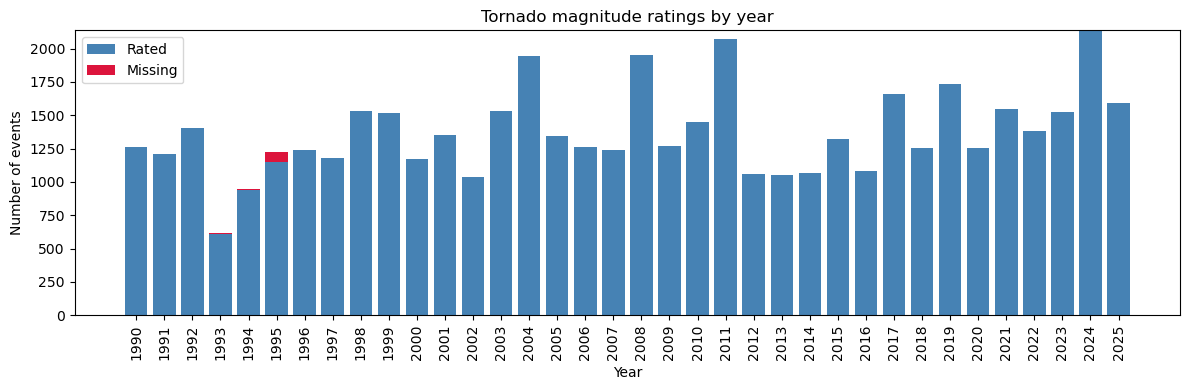

In [3]:
total = len(df)
missing = df["TOR_F_SCALE"].isna()
n_missing = missing.sum()
n_rated = total - n_missing

print(f"Total tornado events : {total}")
print(f"Have a magnitude     : {n_rated}  ({100 * n_rated / total:.1f}%)")
print(f"Missing magnitude    : {n_missing}  ({100 * n_missing / total:.1f}%)")

print("\nBreakdown by rating:")
print(df["TOR_F_SCALE"].value_counts(dropna=False).to_string())

# Plot missing vs rated by year
df["magnitude_missing"] = missing
by_year = df.groupby("year")["magnitude_missing"].agg(total="count", n_missing="sum")
by_year["n_rated"] = by_year["total"] - by_year["n_missing"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_year.index, by_year["n_rated"],  label="Rated",   color="steelblue")
ax.bar(by_year.index, by_year["n_missing"], label="Missing", color="crimson", bottom=by_year["n_rated"])
ax.set_ylabel("Number of events")
ax.set_xlabel("Year")
ax.set_title("Tornado magnitude ratings by year")
plt.xticks(rotation='vertical')
ax.legend()
plt.tight_layout()
plt.show()

### Determine the availability of start and stop time to determine how long a tornado event lasts.

/var/folders/kb/wdqd0hss73q7l_wkc6_6wkjr0000gn/T/ipykernel_91755/173533405.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["begin_dt"] = pd.to_datetime(df["BEGIN_DATE_TIME"])
/var/folders/kb/wdqd0hss73q7l_wkc6_6wkjr0000gn/T/ipykernel_91755/173533405.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["end_dt"]   = pd.to_datetime(df["END_DATE_TIME"])


Total tornado events   : 49437
Have valid duration    : 37573  (76.0%)
Start = end (zero)     : 11864  (24.0%)
Missing end time       : 0  (0.0%)
Missing start time     : 0  (0.0%)

Duration summary (minutes, valid only):
count    37573.0
mean         7.4
std         75.4
min          1.0
25%          2.0
50%          4.0
75%          8.0
max      11520.0


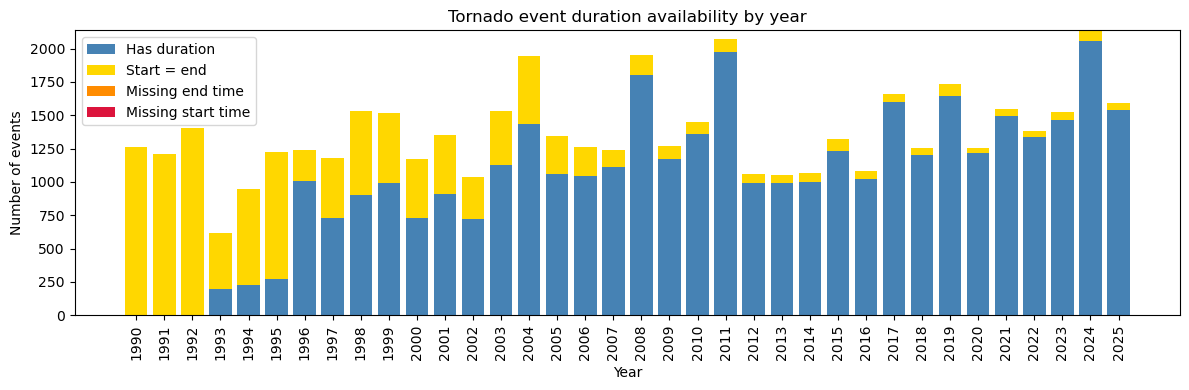

In [4]:
df["begin_dt"] = pd.to_datetime(df["BEGIN_DATE_TIME"])
df["end_dt"]   = pd.to_datetime(df["END_DATE_TIME"])
df["duration_min"] = (df["end_dt"] - df["begin_dt"]).dt.total_seconds() / 60

valid_duration   = df["duration_min"].notna() & (df["duration_min"] > 0)
zero_duration    = df["duration_min"].notna() & (df["duration_min"] == 0)
missing_end      = df["end_dt"].isna()
missing_begin    = df["begin_dt"].isna()

print(f"Total tornado events   : {len(df)}")
print(f"Have valid duration    : {valid_duration.sum()}  ({100 * valid_duration.sum() / len(df):.1f}%)")
print(f"Start = end (zero)     : {zero_duration.sum()}  ({100 * zero_duration.sum() / len(df):.1f}%)")
print(f"Missing end time       : {missing_end.sum()}  ({100 * missing_end.sum() / len(df):.1f}%)")
print(f"Missing start time     : {missing_begin.sum()}  ({100 * missing_begin.sum() / len(df):.1f}%)")

print(f"\nDuration summary (minutes, valid only):")
print(df.loc[valid_duration, "duration_min"].describe().round(1).to_string())

# Plot by year — four categories
by_year = df.groupby("year").apply(
    lambda g: pd.Series({
        "valid":        (g["duration_min"].notna() & (g["duration_min"] > 0)).sum(),
        "zero":         (g["duration_min"].notna() & (g["duration_min"] == 0)).sum(),
        "miss_end":     (g["begin_dt"].notna() & g["end_dt"].isna()).sum(),
        "miss_begin":   g["begin_dt"].isna().sum(),
    })
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_year.index, by_year["valid"],
       label="Has duration",      color="steelblue")
ax.bar(by_year.index, by_year["zero"],
       label="Start = end",       color="gold",
       bottom=by_year["valid"])
ax.bar(by_year.index, by_year["miss_end"],
       label="Missing end time",  color="darkorange",
       bottom=by_year["valid"] + by_year["zero"])
ax.bar(by_year.index, by_year["miss_begin"],
       label="Missing start time", color="crimson",
       bottom=by_year["valid"] + by_year["zero"] + by_year["miss_end"])
ax.set_ylabel("Number of events")
ax.set_xlabel("Year")
ax.set_title("Tornado event duration availability by year")
plt.xticks(rotation="vertical")
ax.legend()
plt.tight_layout()
plt.show()

### How many events are longer than 3.5 hours.

Tri-state tornado lasted about 3.5 hours and is longest lasting tornado in history (assuming it was the same tornado for the whole event). We can remove the less than 1% of events that are longer than that (bad data). We might want to make a more aggresive cut.

We should also maybe look up how this value is calculated. It seems like it would be a hard metric to get for all tornado events. Double checking, it seems like a lot of events just have this as zero minutes. Seems they don't know an end time.

In [5]:
over_3h = df[df["duration_min"] > 210]
print(f"Events lasting more than 3.5 hours: {len(over_3h)}  ({100 * len(over_3h) / len(df):.2f}% of all events)")

print("\n",over_3h[["year", "STATE", "BEGIN_DATE_TIME", "END_DATE_TIME", "duration_min", "TOR_F_SCALE"]].to_string())

Events lasting more than 3.5 hours: 14  (0.03% of all events)

        year           STATE     BEGIN_DATE_TIME       END_DATE_TIME  duration_min TOR_F_SCALE
3949   1993         FLORIDA  05-APR-93 01:00:00  05-APR-93 05:00:00         240.0          F0
3968   1993         FLORIDA  12-MAR-93 22:00:00  13-MAR-93 14:30:00         990.0         NaN
4483   1993         GEORGIA  22-FEB-93 00:10:00  22-FEB-93 23:45:00        1415.0          F1
4676   1994  SOUTH CAROLINA  26-JUN-94 00:00:00  26-JUN-94 23:30:00        1410.0          F2
5078   1994           TEXAS  30-AUG-94 11:33:00  31-AUG-94 22:55:00        2122.0          F0
5931   1995           IDAHO  26-MAY-95 11:15:00  31-MAY-95 17:00:00        7545.0         NaN
9344   1998         GEORGIA  22-JAN-98 18:30:00  30-JAN-98 18:30:00       11520.0          F0
9706   1998    SOUTH DAKOTA  19-JUN-98 18:35:00  20-JUN-98 18:35:00        1440.0          F0
9956   1998         INDIANA  03-MAY-98 15:13:00  03-MAY-98 21:13:00         360.0         

### How complete is the location data and can we calculate how far a tornado traveled assuming a straight line from start to end.

Looks like we might want to toss data from 1990 to 1995 if we want to use the start and end location.

Total events                  : 49437
Has valid path (begin ≠ end)  : 33026  (66.8%)
Start = end (zero distance)   : 11026  (22.3%)
Missing end (has begin)       : 4211  (8.5%)
Missing begin                 : 1174  (2.4%)

Path distance summary (km, valid paths only):
count    33026.00
mean         7.26
std         75.24
min          0.01
25%          1.50
50%          3.80
75%          8.55
max       9054.04


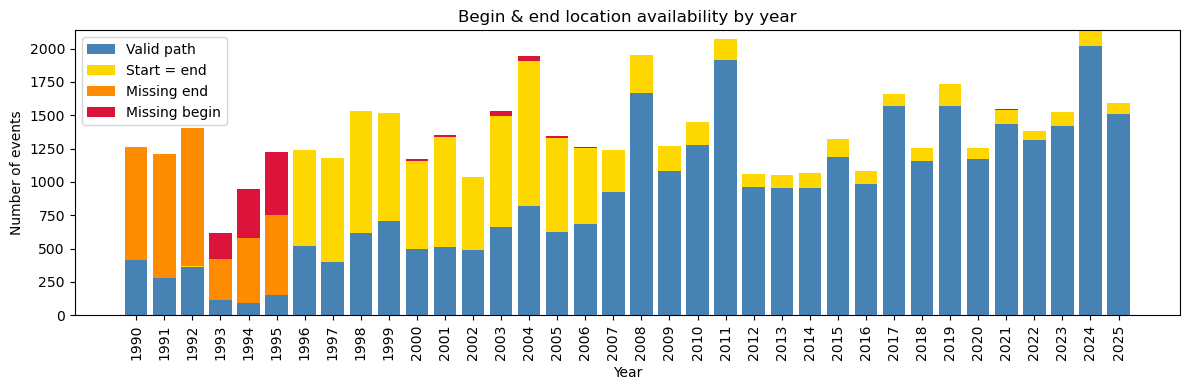

In [6]:
# Check completeness of location data
has_begin = df["BEGIN_LAT"].notna() & df["BEGIN_LON"].notna()
has_end   = df["END_LAT"].notna()   & df["END_LON"].notna()
has_both  = has_begin & has_end
n = len(df)

# Haversine distance (km) between begin and end coordinates
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df["path_km"] = np.nan
df.loc[has_both, "path_km"] = haversine(
    df.loc[has_both, "BEGIN_LAT"].values,
    df.loc[has_both, "BEGIN_LON"].values,
    df.loc[has_both, "END_LAT"].values,
    df.loc[has_both, "END_LON"].values,
)

# Four categories
valid_path    = has_both & (df["path_km"] > 0)
same_location = has_both & (df["path_km"] == 0)
miss_end      = has_begin & ~has_end
miss_begin    = ~has_begin

print(f"Total events                  : {n}")
print(f"Has valid path (begin ≠ end)  : {valid_path.sum()}  ({100 * valid_path.sum() / n:.1f}%)")
print(f"Start = end (zero distance)   : {same_location.sum()}  ({100 * same_location.sum() / n:.1f}%)")
print(f"Missing end (has begin)       : {miss_end.sum()}  ({100 * miss_end.sum() / n:.1f}%)")
print(f"Missing begin                 : {miss_begin.sum()}  ({100 * miss_begin.sum() / n:.1f}%)")

print()
print("Path distance summary (km, valid paths only):")
print(df.loc[valid_path, "path_km"].describe().round(2).to_string())

# Plot by year — four categories
by_year = df.groupby("year").apply(
    lambda g: pd.Series({
        "valid":       (g["path_km"] > 0).sum(),
        "same_loc":    (g["path_km"] == 0).sum(),
        "miss_end":    (g["BEGIN_LAT"].notna() & g["BEGIN_LON"].notna() & ~(g["END_LAT"].notna() & g["END_LON"].notna())).sum(),
        "miss_begin":  (~(g["BEGIN_LAT"].notna() & g["BEGIN_LON"].notna())).sum(),
    })
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_year.index, by_year["valid"],
       label="Valid path",          color="steelblue")
ax.bar(by_year.index, by_year["same_loc"],
       label="Start = end",         color="gold",
       bottom=by_year["valid"])
ax.bar(by_year.index, by_year["miss_end"],
       label="Missing end",         color="darkorange",
       bottom=by_year["valid"] + by_year["same_loc"])
ax.bar(by_year.index, by_year["miss_begin"],
       label="Missing begin",       color="crimson",
       bottom=by_year["valid"] + by_year["same_loc"] + by_year["miss_end"])
ax.set_ylabel("Number of events")
ax.set_xlabel("Year")
ax.set_title("Begin & end location availability by year")
plt.xticks(rotation="vertical")
ax.legend()
plt.tight_layout()
plt.show()

### How many events traveled further 350 km.

Tri-state tornado traveled a total distances of ~350 km. We can remove the less than 1% of events that are longer than that (bad data). We might want to make a more aggresive cut.

The end location might not be a super reliable metric. We could look up how they determine this.

In [7]:
over_350 = df[df["path_km"] > 350]
print(f"Events with path > 350 km: {len(over_350)}  ({100 * len(over_350) / len(df):.2f}% of all events)")
print()
print(over_350[["year", "STATE", "BEGIN_DATE_TIME", "END_DATE_TIME", "path_km", "TOR_F_SCALE"]].to_string())

Events with path > 350 km: 4  (0.01% of all events)

      year           STATE     BEGIN_DATE_TIME       END_DATE_TIME      path_km TOR_F_SCALE
2941  1992  NORTH CAROLINA  22-NOV-92 22:47:00  22-NOV-92 22:47:00   359.276452          F1
8200  1997      WASHINGTON  21-JUL-97 15:15:00  21-JUL-97 15:25:00  7178.548336          F1
8201  1997      WASHINGTON  21-JUL-97 15:15:00  21-JUL-97 15:25:00  7178.548336          F1
8587  1997      CALIFORNIA  18-MAY-97 15:50:00  18-MAY-97 16:00:00  9054.044977          F1


### Exploring the humnan impact, counting deaths as 10 times an injury in an impact calculation

Total events          : 49437
Zero deaths & injuries: 45618
At least one casualty : 3819

Of events with casualties:
  Has direct deaths    : 817  (21.4%)
  Has indirect deaths  : 39  (1.0%)
  Has direct injuries  : 3596  (94.2%)
  Has indirect injuries: 71  (1.9%)

Totals:
  Direct deaths        : 2460
  Indirect deaths      : 48
  Direct injuries      : 34564
  Indirect injuries    : 291

Total impact (deaths×10 + injuries) summary (non-zero events only):
count    3819.0
mean       15.7
std        64.3
min         1.0
25%         1.0
50%         3.0
75%        11.0
max      2760.0


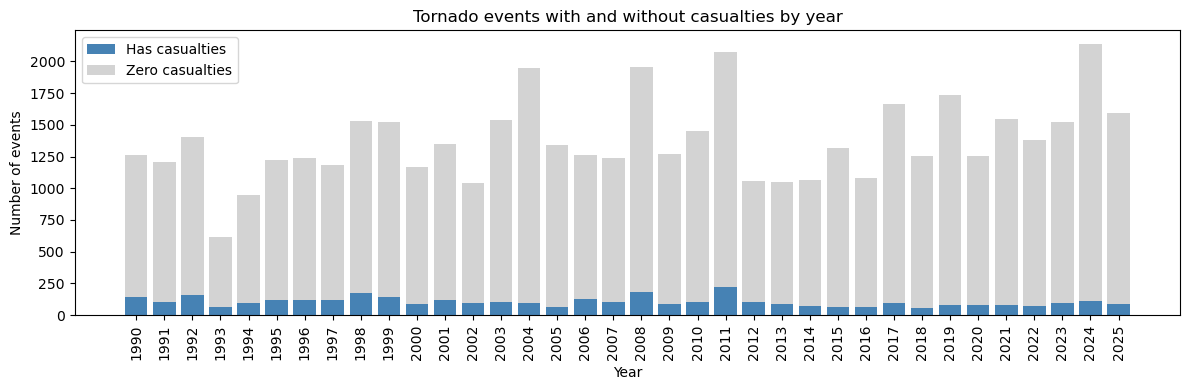

In [8]:
df["total_deaths"]   = df["DEATHS_DIRECT"]   + df["DEATHS_INDIRECT"]
df["total_injuries"] = df["INJURIES_DIRECT"] + df["INJURIES_INDIRECT"]
df["total_impact"]   = df["total_deaths"] * 10 + df["total_injuries"]

n           = len(df)
zero_impact = (df["total_impact"] == 0).sum()
nonzero     = n - zero_impact
nz          = df[df["total_impact"] > 0]

print(f"Total events          : {n}")
print(f"Zero deaths & injuries: {zero_impact}")
print(f"At least one casualty : {nonzero}")
print()
print("Of events with casualties:")
print(f"  Has direct deaths    : {(nz['DEATHS_DIRECT']   > 0).sum()}  ({100 * (nz['DEATHS_DIRECT']   > 0).sum() / nonzero:.1f}%)")
print(f"  Has indirect deaths  : {(nz['DEATHS_INDIRECT'] > 0).sum()}  ({100 * (nz['DEATHS_INDIRECT'] > 0).sum() / nonzero:.1f}%)")
print(f"  Has direct injuries  : {(nz['INJURIES_DIRECT']   > 0).sum()}  ({100 * (nz['INJURIES_DIRECT']   > 0).sum() / nonzero:.1f}%)")
print(f"  Has indirect injuries: {(nz['INJURIES_INDIRECT'] > 0).sum()}  ({100 * (nz['INJURIES_INDIRECT'] > 0).sum() / nonzero:.1f}%)")
print()
print("Totals:")
print(f"  Direct deaths        : {df['DEATHS_DIRECT'].sum()}")
print(f"  Indirect deaths      : {df['DEATHS_INDIRECT'].sum()}")
print(f"  Direct injuries      : {df['INJURIES_DIRECT'].sum()}")
print(f"  Indirect injuries    : {df['INJURIES_INDIRECT'].sum()}")
print()
print("Total impact (deaths×10 + injuries) summary (non-zero events only):")
print(nz["total_impact"].describe().round(1).to_string())

# Plot zero vs nonzero impact by year
by_year = df.groupby("year")["total_impact"].apply(
    lambda x: pd.Series({"nonzero": (x > 0).sum(), "zero": (x == 0).sum()})
).unstack()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_year.index, by_year["nonzero"], label="Has casualties",  color="steelblue")
ax.bar(by_year.index, by_year["zero"],    label="Zero casualties", color="lightgrey",
       bottom=by_year["nonzero"])
ax.set_ylabel("Number of events")
ax.set_xlabel("Year")
ax.set_title("Tornado events with and without casualties by year")
plt.xticks(rotation='vertical')
ax.legend()
plt.tight_layout()
plt.show()

### Exploring the property damage.

Looks like this is cost to property in dollars. Looks like there is a lot of data here. We could use this as some sort of validation set.

These values are not adjusted for inflation so we will likely want to do that if we use them.

DAMAGE_PROPERTY — 38745 non-null of 49437

Sample values:
<StringArray>
[ '25K', '2.5K', '2.5M',   '0K', '250K', '.03K', '.25K',  '25M', '250M',
    '0',   '5K', '.05K',   '5M', '500K',    '3',  '50K',  '.5K',  '50M',
 '1.6B',   '30',   '06',   '1K',   '20',   '00',  '.5M', '150K',   '1M',
  '500', '100K',  '.2M',  '.50',  '75K',  '20K',   '3K',  '30K',  '10K',
   '2K',   '4K',   '2M',  '.4M',  '15K', '.65M',  '56K',  '40K', '175K',
 '350K', '3.5M', '200K', '.01M', '.25M']
Length: 50, dtype: str

Most common values:
DAMAGE_PROPERTY
NaN        10692
0.00K       9791
0           2187
0K          1769
50.00K      1139
10.00K      1062
100.00K     1055
25K          949
250K         917
5.00K        830
50K          786
5K           717
25.00K       705
20.00K       693
10K          571
15.00K       514
500.00K      487
250.00K      479
500K         475
200.00K      474
30.00K       437
75.00K       435
2.5K         431
100K         419
150.00K      364
20K          347
2.5M         339
1.0

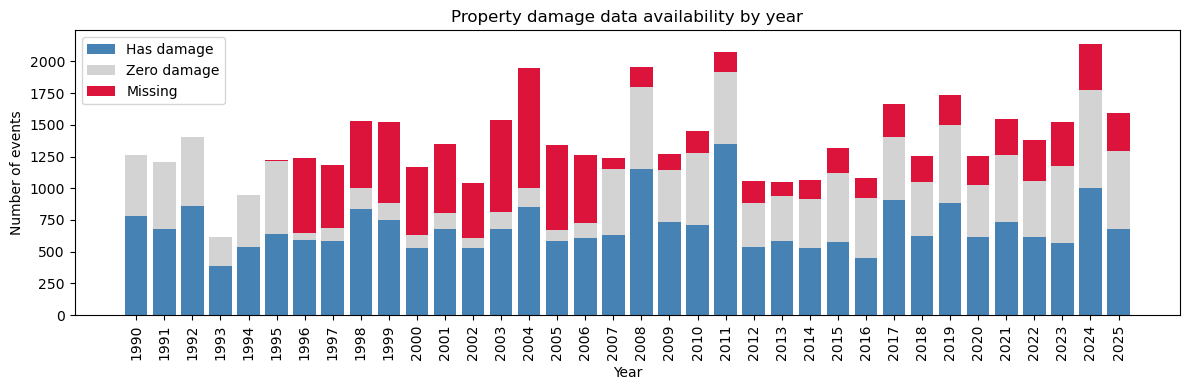

In [9]:
print(f"DAMAGE_PROPERTY — {df['DAMAGE_PROPERTY'].notna().sum()} non-null of {len(df)}")
print()
print("Sample values:")
print(df["DAMAGE_PROPERTY"].dropna().unique()[:50])
print()
print("Most common values:")
print(df["DAMAGE_PROPERTY"].value_counts(dropna=False).head(30).to_string())

# Parse K/M/B suffixes to numeric dollars
def parse_damage(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().upper()
    if val in ("", "0", "0.00"):
        return 0.0
    multipliers = {"K": 1e3, "M": 1e6, "B": 1e9}
    if val[-1] in multipliers:
        try:
            return float(val[:-1]) * multipliers[val[-1]]
        except ValueError:
            return np.nan
    try:
        return float(val)
    except ValueError:
        return np.nan

df["damage_property_usd"] = df["DAMAGE_PROPERTY"].apply(parse_damage)

print()
print("Damage property (USD) summary (non-zero events):")
nz_dmg = df[df["damage_property_usd"] > 0]["damage_property_usd"]
print(nz_dmg.describe().apply(lambda x: f"${x:,.0f}").to_string())
print(f"\nEvents with damage > 0  : {len(nz_dmg)}  ({100 * len(nz_dmg) / len(df):.1f}%)")
print(f"Events with no damage   : {(df['damage_property_usd'] == 0).sum()}")
print(f"Events with missing data: {df['damage_property_usd'].isna().sum()}")

# Plot by year — three categories
by_year = df.groupby("year")["damage_property_usd"].apply(
    lambda x: pd.Series({
        "has_damage": (x > 0).sum(),
        "zero":       (x == 0).sum(),
        "missing":    x.isna().sum(),
    })
).unstack()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_year.index, by_year["has_damage"], label="Has damage",   color="steelblue")
ax.bar(by_year.index, by_year["zero"],       label="Zero damage",  color="lightgrey",
       bottom=by_year["has_damage"])
ax.bar(by_year.index, by_year["missing"],    label="Missing",      color="crimson",
       bottom=by_year["has_damage"] + by_year["zero"])
ax.set_ylabel("Number of events")
ax.set_xlabel("Year")
ax.set_title("Property damage data availability by year")
plt.xticks(rotation='vertical')
ax.legend()
plt.tight_layout()
plt.show()

### Exploring the crop damage.

Looks like this is cost to crops in dollars. There is not much data here. This is probably not very useful to us.

DAMAGE_CROPS — 32365 non-null of 49437

Sample values:
[0 '0' '.05K' '2.5M' '5K' '50K' '.5K' '50M' '500K' '5M' '10K' '4K' '3K'
 '0K' '.7K' '00' '12K' '.3M' '20K' '1K' '70K' '3.5M' '2.2K' '.1M' '.02M'
 '330K' '2K' '2M' '1M' '2.5K' '500' '6K' '80K' '150K' '60K' '600' '43K'
 '22K' '15K' '90K' '0M' '.14M' '.15M' '.23M' '.2K' '.5M' '75K' '40K' '25K'
 '6.5M']

Most common values:
DAMAGE_CROPS
0.00K      22017
NaN        17072
0           3876
0           3827
0K           333
5.00K        162
5K           161
10.00K       155
1.00K        109
50K          101
2.00K        100
10K           89
1K            88
100.00K       83
2K            72
50.00K        69
.5K           51
20.00K        46
100K          43
20K           42
500.00K       39
15K           36
3.00K         36
25.00K        35
25K           33
250.00K       32
500K          30
15.00K        30
0.50K         30
.05K          29

Damage crops (USD) summary (non-zero events):
count         $2,297
mean        $228,021
std       $

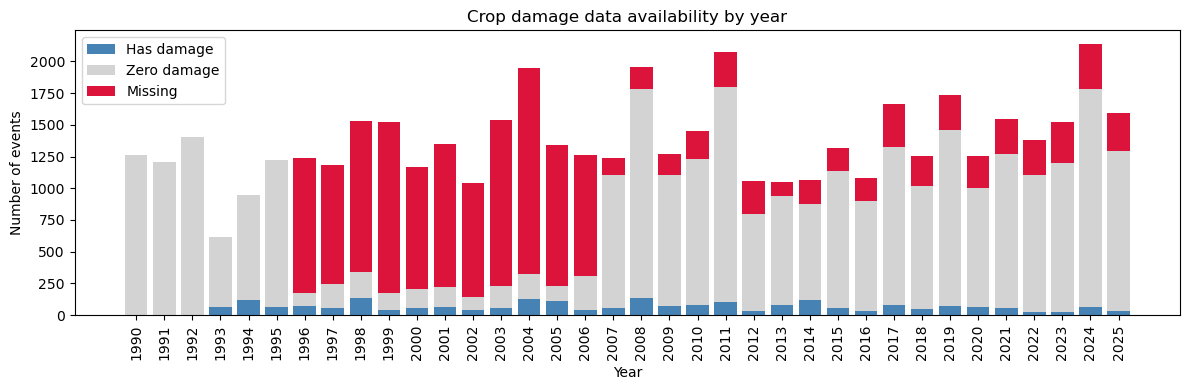

In [10]:
print(f"DAMAGE_CROPS — {df['DAMAGE_CROPS'].notna().sum()} non-null of {len(df)}")
print()
print("Sample values:")
print(df["DAMAGE_CROPS"].dropna().unique()[:50])
print()
print("Most common values:")
print(df["DAMAGE_CROPS"].value_counts(dropna=False).head(30).to_string())

df["damage_crops_usd"] = df["DAMAGE_CROPS"].apply(parse_damage)

print()
print("Damage crops (USD) summary (non-zero events):")
nz_crops = df[df["damage_crops_usd"] > 0]["damage_crops_usd"]
print(nz_crops.describe().apply(lambda x: f"${x:,.0f}").to_string())
print(f"\nEvents with damage > 0  : {len(nz_crops)}  ({100 * len(nz_crops) / len(df):.1f}%)")
print(f"Events with no damage   : {(df['damage_crops_usd'] == 0).sum()}")
print(f"Events with missing data: {df['damage_crops_usd'].isna().sum()}")

# Plot by year — three categories
by_year = df.groupby("year")["damage_crops_usd"].apply(
    lambda x: pd.Series({
        "has_damage": (x > 0).sum(),
        "zero":       (x == 0).sum(),
        "missing":    x.isna().sum(),
    })
).unstack()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_year.index, by_year["has_damage"], label="Has damage",  color="steelblue")
ax.bar(by_year.index, by_year["zero"],       label="Zero damage", color="lightgrey",
       bottom=by_year["has_damage"])
ax.bar(by_year.index, by_year["missing"],    label="Missing",     color="crimson",
       bottom=by_year["has_damage"] + by_year["zero"])
ax.set_ylabel("Number of events")
ax.set_xlabel("Year")
ax.set_title("Crop damage data availability by year")
plt.xticks(rotation='vertical')
ax.legend()
plt.tight_layout()
plt.show()